# Adaptive Ar-39 blip energy regression under changing noise (VQ-VAE + linear energy head)
This notebook modifies the original ROI-finder training to:
- create inputs as (signal + synthesized noise)
- regress per-blip energy with an *explicit linear* energy model E = a * Q + b
- train a VQ-VAE backbone for denoising + a supervised energy head
- stress-test adaptation across noise conditions


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import label
import matplotlib.pyplot as plt


In [2]:
# -------- Paths (edit as needed) --------
DOPED_DIR = "/scratch/7DayLifetime/mking/1000_evts_doped"
STD_DIR   = "/scratch/7DayLifetime/mking/1000_evts_standard"

# Choose training set (doped) and optional OOD test set (standard)
train_signal_path = f"{DOPED_DIR}/signal.raw"
train_noise_path  = f"{DOPED_DIR}/noise.raw"
train_roi_path    = f"{DOPED_DIR}/roi.npy"

test_signal_path  = f"{STD_DIR}/signal.raw"
test_noise_path   = f"{STD_DIR}/noise.raw"
test_roi_path     = f"{STD_DIR}/roi.npy"


In [3]:
# -------- Load memmaps --------
N_EVT, N_CH, N_TICK = 1000, 1280, 2128
dtype = np.float32

train_signal_mm = np.memmap(train_signal_path, dtype=dtype, mode="r", shape=(N_EVT, N_CH, N_TICK))
train_noise_mm  = np.memmap(train_noise_path,  dtype=dtype, mode="r", shape=(N_EVT, N_CH, N_TICK))
train_roi       = np.load(train_roi_path)

test_signal_mm  = np.memmap(test_signal_path, dtype=dtype, mode="r", shape=(N_EVT, N_CH, N_TICK))
test_noise_mm   = np.memmap(test_noise_path,  dtype=dtype, mode="r", shape=(N_EVT, N_CH, N_TICK))
test_roi        = np.load(test_roi_path)

# TPC 0 Plane Z (channels 800-1039)
CH0, CH1 = 800, 1040
train_signal_raw = np.asarray(train_signal_mm[:, CH0:CH1, :], dtype=np.float32)
train_noise_raw  = np.asarray(train_noise_mm[:,  CH0:CH1, :], dtype=np.float32)
train_roi_raw    = np.asarray(train_roi[:,      CH0:CH1, :], dtype=np.uint8)

test_signal_raw = np.asarray(test_signal_mm[:, CH0:CH1, :], dtype=np.float32)
test_noise_raw  = np.asarray(test_noise_mm[:,  CH0:CH1, :], dtype=np.float32)
test_roi_raw    = np.asarray(test_roi[:,      CH0:CH1, :], dtype=np.uint8)

print(train_signal_raw.shape, train_noise_raw.shape, train_roi_raw.shape)


(1000, 240, 2128) (1000, 240, 2128) (1000, 240, 2128)


In [67]:
# -------- Chunking to (N*10, 1, 240, 212) like your original notebook --------
def chunkify(arr, n_events=1000, H=240, W=2128, chunkW=212, n_chunks=10):
    arr = arr[:, None, :, :2120].reshape(n_events, 1, H, n_chunks, chunkW)
    return arr.swapaxes(1, 3).reshape(n_events*n_chunks, 1, H, chunkW)

train_signal_c = chunkify(train_signal_raw)
train_noise_c  = chunkify(train_noise_raw)
train_roi_c    = chunkify(train_roi_raw)

test_signal_c = chunkify(test_signal_raw)
test_noise_c  = chunkify(test_noise_raw)
test_roi_c    = chunkify(test_roi_raw)

print(train_signal_c.shape, train_noise_c.shape, train_roi_c.shape)


(10000, 1, 240, 212) (10000, 1, 240, 212) (10000, 1, 240, 212)


In [68]:
# -------- Noise synthesis (domain randomization) --------
def synthesize_noise(n, noise_pool=None,
                     scale_range=(0.5, 3.0),
                     mix_prob=0.5,
                     drift_prob=0.3):
    # multiplicative scaling (log-uniform)
    g = float(np.exp(np.random.uniform(np.log(scale_range[0]), np.log(scale_range[1]))))
    out = n.copy()

    # mix noise textures
    if noise_pool is not None and np.random.rand() < mix_prob:
        j = np.random.randint(0, len(noise_pool))
        out = 0.5*out + 0.5*noise_pool[j]

    # slow baseline drift across time ticks
    if np.random.rand() < drift_prob:
        W = out.shape[-1]
        drift = np.linspace(np.random.uniform(-1,1), np.random.uniform(-1,1), W).astype(np.float32)
        out = out + drift[None, None, :]

    return g*out, g

def per_sample_norm(x, n):
    mu = float(n.mean())
    sd = float(n.std() + 1e-6)
    sd = np.maximum(sd, 1.0)
    return (x - mu)/sd, (n - mu)/sd, mu, sd


In [69]:
# -------- Blip extraction + energy labels (from *signal-only* inside ROI) --------
def extract_blips(roi_img, min_pixels=3):
    m = roi_img[0].astype(bool)  # (H,W)
    cc, ncc = label(m)
    comps = []
    for k in range(1, ncc+1):
        comp = (cc == k)
        if comp.sum() >= min_pixels:
            comps.append(comp)
    return comps

def blip_true_charge(signal_img, comp_mask):
    # "charge" proxy in ADC units (sum over pixels in component)
    return float(signal_img[0][comp_mask].sum())

# Linear energy model: E_true = k_cal * Q_true + b_cal
# Set k_cal,b_cal based on calibration; or leave b_cal=0 and fit k_cal post-hoc.
k_cal = 1.0
b_cal = 0.0


In [79]:
class Ar39BlipDataset(Dataset):
    def __init__(self, signal_c, noise_c, roi_c, noise_pool=None,
                 scale_range=(0.5,3.0), return_roi=True,
                 min_pixels=3, max_blips=100, E_SCALE=1e3):
        self.signal = signal_c
        self.noise  = noise_c
        self.roi    = roi_c
        self.noise_pool = noise_pool
        self.scale_range = scale_range
        self.return_roi = return_roi
        self.max_blips = max_blips
        self.E_SCALE = E_SCALE

        # ---- PRECOMPUTE blip indices + energies ONCE ----
        self.blip_idx = []
        self.blip_E   = []
        for i in range(len(self.signal)):
            r = self.roi[i]
            comps = extract_blips(r, min_pixels=min_pixels)

            # convert each component mask -> flat indices
            idx_list = []
            E_list = []
            s = self.signal[i]  # (1,H,W) raw

            for cm in comps[:max_blips]:
                flat_idx = np.flatnonzero(cm.ravel()).astype(np.int64)
                idx_list.append(torch.from_numpy(flat_idx).long())
                q = float(s[0].ravel()[flat_idx].sum())
                E = (k_cal*q + b_cal)/E_SCALE
                E_list.append(E)

            self.blip_idx.append(idx_list)
            self.blip_E.append(E_list)

    def __len__(self):
        return len(self.signal)

    def __getitem__(self, idx):
        s = self.signal[idx]  # (1,H,W)
        n = self.noise[idx]
        r = self.roi[idx]

        n_syn, g = synthesize_noise(n, noise_pool=self.noise_pool, scale_range=self.scale_range)
        x = s + n_syn

        # IMPORTANT: per-sample norm should use noise-only stats
        x_n, n_n, mu, sd = per_sample_norm(x, n_syn)
        s_n, _, _, _ = per_sample_norm(s, n_syn)

        sample = {
            "x": torch.from_numpy(np.concatenate([x_n, n_n], axis=0)).float(),  # (2,H,W)
            "y_denoise": torch.from_numpy(s_n).float(),                         # (1,H,W)
            "noise_stats": torch.tensor([mu, sd, g], dtype=torch.float32),
            "blip_idx": self.blip_idx[idx],   # list[np.int64[?]]
            "blip_E":   self.blip_E[idx],     # list[float]
        }
        if self.return_roi:
            sample["roi"] = torch.from_numpy((r > 0).astype(np.float32)).float()
        return sample


def collate_blips(batch, pad_val=-1):
    x = torch.stack([b["x"] for b in batch])
    y = torch.stack([b["y_denoise"] for b in batch])
    stats = torch.stack([b["noise_stats"] for b in batch])

    blip_idx = [b["blip_idx"] for b in batch]  # list of list of 1D LongTensors
    blip_E   = [b["blip_E"] for b in batch]    # list of list of floats

    B = len(batch)
    K = max(len(li) for li in blip_idx) if B else 0
    L = max((t.numel() for li in blip_idx for t in li), default=0)

    idx_pad = torch.full((B, K, L), pad_val, dtype=torch.long)
    E_pad   = torch.full((B, K), float("nan"), dtype=torch.float32)
    valid   = torch.zeros((B, K), dtype=torch.bool)

    for i in range(B):
        for k, (idx_t, E) in enumerate(zip(blip_idx[i], blip_E[i])):
            l = idx_t.numel()
            idx_pad[i, k, :l] = idx_t
            E_pad[i, k] = float(E)
            valid[i, k] = True

    out = {"x": x, "y_denoise": y, "noise_stats": stats,
           "idx_pad": idx_pad, "E_pad": E_pad, "valid": valid}
    if "roi" in batch[0]:
        out["roi"] = torch.stack([b["roi"] for b in batch])
    return out



In [88]:
# -------- Build loaders --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# train: use noise pool to mix realizations
train_ds = Ar39BlipDataset(train_signal_c, train_noise_c, train_roi_c,
                           noise_pool=train_noise_c,
                           scale_range=(0.5,3.0))

# OOD test: stronger noise shifts
test_ds = Ar39BlipDataset(test_signal_c, test_noise_c, test_roi_c,
                          noise_pool=test_noise_c,
                          scale_range=(0.2,6.0))



train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2,
    collate_fn=collate_blips
)

test_loader  = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2,
    collate_fn=collate_blips
)

In [89]:
# -------- VQ-VAE blocks --------
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c, c, 3, padding=1),
        )
    def forward(self, x):
        return F.relu(x + self.net(x))

class Encoder(nn.Module):
    def __init__(self, in_ch=2, hid=64, z_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, hid, 4, stride=2, padding=1),  # 240x212 -> 120x106
            nn.ReLU(True),
            nn.Conv2d(hid, hid, 4, stride=2, padding=1),    # 60x53
            nn.ReLU(True),
            ResBlock(hid),
            nn.Conv2d(hid, z_ch, 1),
        )
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, out_ch=1, hid=64, z_ch=64):
        super().__init__()
        self.pre = nn.Sequential(
            nn.Conv2d(z_ch, hid, 1),
            ResBlock(hid),
        )
        self.up = nn.Sequential(
            nn.ConvTranspose2d(hid, hid, 4, stride=2, padding=1),  # 60x53 -> 120x106
            nn.ReLU(True),
            nn.ConvTranspose2d(hid, hid, 4, stride=2, padding=1),  # 120x106 -> 240x212
            nn.ReLU(True),
        )
        self.out = nn.Conv2d(hid, out_ch, 3, padding=1)

    def forward(self, z, return_features=False):
        h = self.pre(z)
        h = self.up(h)
        y = self.out(h)
        if return_features:
            return y, h
        return y


class VectorQuantizer(nn.Module):
    def __init__(self, n_codes=512, code_dim=64, beta=0.25):
        super().__init__()
        self.n_codes = n_codes
        self.code_dim = code_dim
        self.beta = beta
        self.codebook = nn.Embedding(n_codes, code_dim)
        self.codebook.weight.data.uniform_(-1/n_codes, 1/n_codes)

    def forward(self, z_e):
        # z_e: (B,C,H,W) -> (B*H*W, C)
        B,C,H,W = z_e.shape
        z = z_e.permute(0,2,3,1).contiguous().view(-1, C)
        # distances
        d = (z**2).sum(1, keepdim=True) + (self.codebook.weight**2).sum(1) - 2*z @ self.codebook.weight.t()
        idx = torch.argmin(d, dim=1)
        z_q = self.codebook(idx).view(B,H,W,C).permute(0,3,1,2).contiguous()

        # losses
        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commit_loss = F.mse_loss(z_e, z_q.detach())
        vq_loss = codebook_loss + self.beta * commit_loss

        # straight-through
        z_q_st = z_e + (z_q - z_e).detach()
        return z_q_st, vq_loss, idx.view(B,H,W)


In [90]:
# -------- Full model: VQ-VAE + energy head with explicit linear scaling --------
class AdaptiveVQVAE(nn.Module):
    def __init__(self, in_ch=2, hid=64, z_ch=64, n_codes=512):
        super().__init__()
        self.enc = Encoder(in_ch=in_ch, hid=hid, z_ch=z_ch)
        self.vq  = VectorQuantizer(n_codes=n_codes, code_dim=z_ch)
        self.dec = Decoder(out_ch=1, hid=hid, z_ch=z_ch)

        # Per-pixel nonnegative charge/energy density map head
        self.energy_map_head = nn.Sequential(
            nn.Conv2d(z_ch, hid, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hid, 1, 1),
        )

        # Explicit linear scaling E = a * Q + b (learnable scalars)
        self.a = nn.Parameter(torch.tensor(1.0))
        self.b = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        z_e = self.enc(x)                 # (B,z_ch,60,53)
        z_q, vq_loss, _ = self.vq(z_e)    # (B,z_ch,60,53)
        denoise, h = self.dec(z_q, return_features=True)  # h: (B,hid,240,212)
        energy_map = self.energy_map_head(h)              # (B,1,240,212)
        return denoise, energy_map, vq_loss


In [91]:
def blip_energy_loss_fast(energy_map, idx_pad, E_pad, valid, a, b):
    # energy_map: (B,1,H,W)
    B = energy_map.size(0)
    em = energy_map[:, 0].reshape(B, -1)  # (B, HW)

    idx_pad = idx_pad.to(em.device, non_blocking=True)   # (B,K,L)
    E_pad   = E_pad.to(em.device, non_blocking=True)     # (B,K)
    valid   = valid.to(em.device, non_blocking=True)     # (B,K)

    idx_safe = idx_pad.clamp_min(0)  # replace -1 with 0 for gather

    B, K, L = idx_safe.shape
    emK = em[:, None, :].expand(B, K, em.shape[1])  # (B,K,HW)

    gathered = emK.gather(2, idx_safe)              # (B,K,L)
    gathered = gathered * (idx_pad != -1).float()   # zero out padded positions

    Q_pred = gathered.sum(dim=2)                    # (B,K)
    E_pred = a * Q_pred + b                         # (B,K)

    return F.smooth_l1_loss(E_pred[valid], E_pad[valid], beta=1.0) if valid.any() \
           else torch.tensor(0.0, device=em.device)


In [92]:
model = AdaptiveVQVAE(in_ch=2, hid=64, z_ch=64, n_codes=512).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-5)

In [93]:
print("device:", device)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("model device:", next(model.parameters()).device)


batch = next(iter(train_loader))

t0 = time.time()
x = batch["x"].to(device, non_blocking=True)
y = batch["y_denoise"].to(device, non_blocking=True)
if device.type == "cuda":
    torch.cuda.synchronize()
t1 = time.time()

denoise, energy_map, vq_loss = model(x)
if device.type == "cuda":
    torch.cuda.synchronize()
t2 = time.time()

recon_loss = F.mse_loss(denoise, y)
E_loss = blip_energy_loss_fast(energy_map, batch["idx_pad"], batch["E_pad"], batch["valid"], model.a, model.b)
loss = recon_loss + E_loss + vq_loss
if device.type == "cuda":
    torch.cuda.synchronize()
t3 = time.time()

opt.zero_grad(set_to_none=True)
loss.backward()
opt.step()
if device.type == "cuda":
    torch.cuda.synchronize()
t4 = time.time()

print(f"to(device): {t1-t0:.3f}s | forward: {t2-t1:.3f}s | loss: {t3-t2:.3f}s | backward+step: {t4-t3:.3f}s")

print("len(train_loader):", len(train_loader))
print("batch_size:", train_loader.batch_size)



device: cuda
cuda available: True
gpu: NVIDIA A100 80GB PCIe MIG 4g.40gb
model device: cuda:0
to(device): 0.002s | forward: 0.044s | loss: 0.002s | backward+step: 0.075s
len(train_loader): 157
batch_size: 64


In [94]:
import time
def vq_weight(epoch, warmup=5, max_w=0.25):
    return max_w * min(1.0, epoch / warmup)



# -------- Training loop (supervised; domain-randomized noise) --------

from tqdm.auto import tqdm
import time
import torch.nn.functional as F

def run_epoch(loader, train=True, lam_E=1.0, lam_recon=1.0, lam_vq=1.0):
    model.train(train)

    total_loss = total_recon = total_E = total_vq = 0.0
    n = 0
    start_time = time.time()

    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        y = batch["y_denoise"].to(device, non_blocking=True)

        denoise, energy_map, vq_loss = model(x)

        recon_loss = F.mse_loss(denoise, y)
        E_loss = blip_energy_loss_fast(
            energy_map, batch["idx_pad"], batch["E_pad"], batch["valid"], model.a, model.b
        )

        loss = lam_recon*recon_loss + lam_E*E_loss + lam_vq*vq_loss

        if train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_E += E_loss.item()
        total_vq += vq_loss.item()
        n += 1

    return {
        "loss": total_loss / max(n, 1),
        "recon": total_recon / max(n, 1),
        "E": total_E / max(n, 1),
        "vq": total_vq / max(n, 1),
        "time": time.time() - start_time
    }



save_dir = "./checkpoints"
os.makedirs(save_dir, exist_ok=True)

best_total = float("inf")
best_recon = float("inf")
best_vq = float("inf")

best_epochs = {
    "total": None,
    "recon": None,
    "vq": None
    }

for epoch in range(20):

    lam_vq = vq_weight(epoch, warmup=5, max_w=0.25)

    print(f"\n===== Epoch {epoch:02d} (lam_vq={lam_vq:.3f}) =====")

    tr = run_epoch(train_loader, train=True,  lam_vq=lam_vq)
    te = run_epoch(test_loader,  train=False, lam_vq=lam_vq)

    print(f"Train | loss={tr['loss']:.4f} recon={tr['recon']:.4f} E={tr['E']:.4f} vq={tr['vq']:.4f}")
    print(f"Test  | loss={te['loss']:.4f} recon={te['recon']:.4f} E={te['E']:.4f} vq={te['vq']:.4f}")

    # -------------------------------
    # CHECKPOINTING (based on TEST)
    # -------------------------------

    # Lowest TOTAL loss
    if te["loss"] < best_total:
        best_total = te["loss"]
        best_epochs["total"] = epoch
        torch.save(model.state_dict(), os.path.join(save_dir, "best_total.pt"))
        print("  >> Saved best TOTAL loss model")

    # Lowest RECON loss
    if te["recon"] < best_recon:
        best_recon = te["recon"]
        best_epochs["recon"] = epoch
        torch.save(model.state_dict(), os.path.join(save_dir, "best_recon.pt"))
        print("  >> Saved best RECON loss model")

    # Lowest VQ loss
    if te["vq"] < best_vq:
        best_vq = te["vq"]
        best_epochs["vq"] = epoch
        torch.save(model.state_dict(), os.path.join(save_dir, "best_vq.pt"))
        print("  >> Saved best VQ loss model")

    print(f"Calibration: a={float(model.a.detach()):.4f} b={float(model.b.detach()):.4f}")


  


===== Epoch 00 (lam_vq=0.000) =====
Train | loss=1.2625 recon=0.1195 E=1.1430 vq=0.3719
Test  | loss=0.0205 recon=0.0081 E=0.0124 vq=0.6458
  >> Saved best TOTAL loss model
  >> Saved best RECON loss model
  >> Saved best VQ loss model
Calibration: a=0.9983 b=0.0020

===== Epoch 01 (lam_vq=0.050) =====
Train | loss=0.1789 recon=0.1248 E=0.0172 vq=0.7374
Test  | loss=0.0546 recon=0.0088 E=0.0094 vq=0.7275
Calibration: a=0.9982 b=0.0020

===== Epoch 02 (lam_vq=0.100) =====
Train | loss=0.2258 recon=0.1234 E=0.0126 vq=0.8975
Test  | loss=0.1139 recon=0.0087 E=0.0055 vq=0.9969
Calibration: a=0.9982 b=0.0021

===== Epoch 03 (lam_vq=0.150) =====
Train | loss=0.4940 recon=0.1236 E=0.0074 vq=2.4203
Test  | loss=0.7841 recon=0.0084 E=0.0030 vq=5.1511
Calibration: a=0.9981 b=0.0021

===== Epoch 04 (lam_vq=0.200) =====
Train | loss=2.4308 recon=0.1218 E=0.0048 vq=11.5211
Test  | loss=2.9632 recon=0.0086 E=0.0024 vq=14.7607
Calibration: a=0.9981 b=0.0019

===== Epoch 05 (lam_vq=0.250) =====
Train

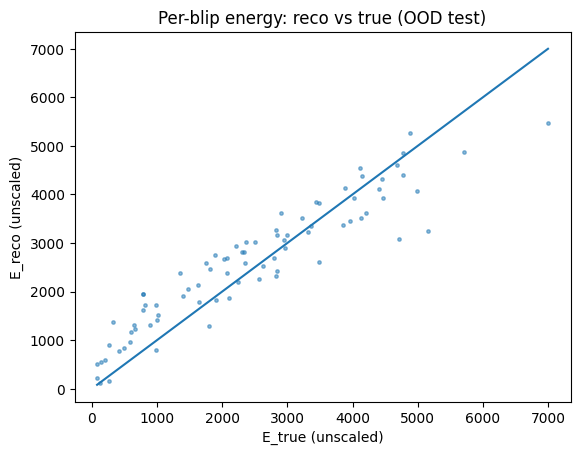

MAE: 495.4332 RMSE: 614.1585


In [97]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def eval_energy_scatter(loader, E_SCALE=1e3, max_batches=None):
    model.eval()
    E_true_list = []
    E_pred_list = []
    sd_list = []
    g_list = []

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = batch["x"].to(device, non_blocking=True)
        denoise, energy_map, _ = model(x)

        # flatten energy map
        B = energy_map.size(0)
        em = energy_map[:, 0].reshape(B, -1)  # (B, HW)

        idx_pad = batch["idx_pad"].to(device, non_blocking=True)   # (B,K,L)
        E_pad   = batch["E_pad"].to(device, non_blocking=True)     # (B,K)  (scaled)
        valid   = batch["valid"].to(device, non_blocking=True)     # (B,K)

        idx_safe = idx_pad.clamp_min(0)
        B, K, L = idx_safe.shape

        emK = em[:, None, :].expand(B, K, em.shape[1])
        gathered = emK.gather(2, idx_safe)
        gathered = gathered * (idx_pad != -1).float()
        Q_pred = gathered.sum(dim=2)                 # (B,K)

        E_pred_scaled = model.a * Q_pred + model.b   # (B,K)

        # pull valid entries
        E_true_scaled = E_pad[valid]
        E_pred_scaled = E_pred_scaled[valid]

        # unscale to physical-ish units
        E_true = (E_true_scaled * E_SCALE).detach().cpu().numpy()
        E_pred = (E_pred_scaled * E_SCALE).detach().cpu().numpy()

        # optional: noise metadata
        if "noise_stats" in batch:
            stats = batch["noise_stats"].cpu().numpy()  # (B,3): mu, sd, g
            # repeat each sample's sd,g for its number of valid blips
            # easiest: just skip unless you really need it for coloring

        E_true_list.append(E_true)
        E_pred_list.append(E_pred)

    if len(E_true_list) == 0:
        return None, None

    E_true = np.concatenate(E_true_list)
    E_pred = np.concatenate(E_pred_list)
    return E_true, E_pred

E_true, E_pred = eval_energy_scatter(test_loader, E_SCALE=1e4, max_batches=30)

plt.figure()
plt.scatter(E_true, E_pred, s=6, alpha=0.5)
mn = min(E_true.min(), E_pred.min())
mx = max(E_true.max(), E_pred.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("E_true (unscaled)")
plt.ylabel("E_reco (unscaled)")
plt.title("Per-blip energy: reco vs true (OOD test)")
plt.show()

# quick metrics
mae = np.mean(np.abs(E_pred - E_true))
rmse = np.sqrt(np.mean((E_pred - E_true)**2))
print("MAE:", mae, "RMSE:", rmse)
